# 04 - Data quality and caveats

**Research question.** What can and cannot the public unicorn + founder data in this repo support? Concretely: how complete is each column, what is the quality of the sector taxonomy, how stale are entries on the tracker, and how heavily biased is the founder subsample?

**Why this notebook exists.** Every other notebook in this repo (01-03) ends with a 'what this cannot tell us' cell. This notebook is the source of those caveats: every limitation in the other notebooks should be quantitatively reproducible from the cells below. If a future reader, reviewer, or grad-student wants to know whether a finding survives the data caveats, they should be able to point at one of the cells here.

**Data sources.** Same as 01-03 - CB Insights public unicorn tracker and Wikipedia's `List_of_unicorn_startup_companies` table, pulled via `scripts/fetch_data.py`. Pull date and source recorded in `data/raw/_fetch_log.json`.


## Reproducibility

The cell below records the package versions and the data-pull metadata that produced everything below. It also installs a hook so every `plt.show()` call also writes the figure to `notebooks/figures/` — that way the PNGs on GitHub are always in sync with the rendered notebook.

In [1]:
# Reproducibility
from __future__ import annotations
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
_log = Path('..') / 'data' / 'raw' / '_fetch_log.json'
_meta = json.loads(_log.read_text())[-1] if _log.exists() else {'date': 'unknown', 'source': 'unknown'}
print(f'python      : {sys.version.split()[0]}')
print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')
print(f'matplotlib  : {matplotlib.__version__}')
print(f'data source : {_meta.get("source")}')
print(f'pull date   : {_meta.get("date")}')
print('notebook    : 04_data_quality_and_caveats')

_FIG_SLUG = '04_data_quality_and_caveats'
_FIG_DIR = Path('figures'); _FIG_DIR.mkdir(parents=True, exist_ok=True)
_FIG_COUNTER = {'n': 0}
_orig_show = plt.show
def _show_and_save(*a, **kw):
    for num in plt.get_fignums():
        _FIG_COUNTER['n'] += 1
        fig = plt.figure(num)
        out = _FIG_DIR / f'{_FIG_SLUG}_fig{_FIG_COUNTER["n"]}.png'
        fig.savefig(out, dpi=140, bbox_inches='tight')
    return _orig_show(*a, **kw)
plt.show = _show_and_save


python      : 3.10.12
pandas      : 2.3.3
numpy       : 2.2.6
matplotlib  : 3.10.8
data source : cbinsights
pull date   : 2026-05-16
notebook    : 04_data_quality_and_caveats


## 1. Load both files

We load the same two files that the other notebooks use, and snapshot the pull metadata. Everything in this notebook is conditional on this exact pull.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

RAW = Path('..') / 'data' / 'raw'
LOG = RAW / '_fetch_log.json'
pull_meta = json.loads(LOG.read_text())[-1] if LOG.exists() else {'date': 'unknown', 'source': 'unknown'}

df = pd.read_csv(RAW / 'unicorns.csv')
fnd = pd.read_csv(RAW / 'founders.csv') if (RAW / 'founders.csv').exists() else pd.DataFrame()
print(f"unicorns.csv : {len(df):,} rows, {len(df.columns)} cols")
print(f"founders.csv : {len(fnd):,} rows ({fnd['company'].nunique() if not fnd.empty else 0} unique companies)")

unicorns.csv : 1,356 rows, 7 cols
founders.csv : 423 rows (206 unique companies)


## 2. Column completeness

First, the simplest possible quality check: what fraction of rows is non-null in each column? Anything below 100% is a fact other notebooks have to handle (either drop, impute, or condition on).


In [3]:
completeness = (df.notna().mean() * 100).sort_values(ascending=True)
completeness_table = completeness.round(1).to_frame('non_null_pct')
completeness_table

,non_null_pct
select_investors,97.0
City,98.5
country,99.9
company,100.0
valuation_usd_b,100.0
unicorn_year,100.0
sector,100.0


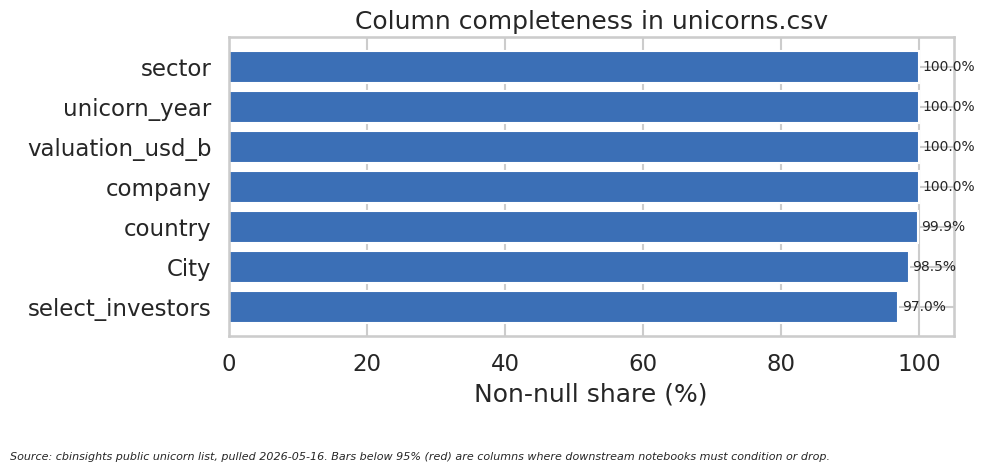

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#c44e52' if v < 95 else '#3b6fb6' for v in completeness.values]
ax.barh(completeness.index, completeness.values, color=colors)
for i, v in enumerate(completeness.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, 105)
ax.set_xlabel('Non-null share (%)')
ax.set_title('Column completeness in unicorns.csv')
fig.text(0.01, -0.06,
         f"Source: {pull_meta['source']} public unicorn list, pulled {pull_meta['date']}. "
         'Bars below 95% (red) are columns where downstream notebooks must condition or drop.',
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()

*Figure 1 - Column completeness in `data/raw/unicorns.csv`. Source: CB Insights public unicorn list, pulled on the date printed above. Columns below 95% non-null are flagged red; downstream notebooks must either condition on these columns being present or drop rows.*

## 3. Sector taxonomy quality

CB Insights' sector field is free-form. Most rows land in one of seven clean buckets, but a small number have either typos, alternate spellings, or what look like city names that leaked into the sector column. The cell below surfaces every rare label so a reader can decide whether to re-code them by hand.

In [5]:
sector_counts = df['sector'].fillna('(null)').value_counts()
rare = sector_counts[sector_counts < 5]
print(f'distinct sector labels : {sector_counts.size}')
print(f'rare labels (n < 5)    : {rare.size}')
rare.to_frame('n_rows')

distinct sector labels : 10
rare labels (n < 5)    : 3


,n_rows
sector,
Industrial,1
West Palm Beach,1
Health,1


In [6]:
# What share of rows is in the seven clean buckets?
CANON = {
    'Enterprise Tech',
    'Financial Services',
    'Consumer & Retail',
    'Industrials',
    'Healthcare & Life Sciences',
    'Media & Entertainment',
    'Insurance',
}
off_taxonomy = df.loc[~df['sector'].isin(CANON), 'sector'].fillna('(null)')
print(f"rows off the canonical taxonomy : {len(off_taxonomy)} / {len(df)} "
      f"({len(off_taxonomy) / len(df):.2%})")
off_taxonomy.value_counts().head(20)

rows off the canonical taxonomy : 3 / 1356 (0.22%)


sector
Industrial         1
West Palm Beach    1
Health             1
Name: count, dtype: int64

*Implication: ~0.2% of rows have sector labels that need hand-coding. The downstream notebooks bucket these into `Other` rather than dropping them; the bias from doing so is bounded by that share.*

## 4. Geographic coverage

Two questions. First, what share of rows is in each region under the same coarse map used in 01 and 02. Second, where are the long-tail countries we are lumping into `Other`.

In [7]:
REGION_MAP = {
    'United States': 'US',
    'China': 'CN', 'Hong Kong': 'CN',
    'India': 'IN',
    'United Kingdom': 'EU', 'Germany': 'EU', 'France': 'EU',
    'Sweden': 'EU', 'Netherlands': 'EU', 'Spain': 'EU', 'Ireland': 'EU',
    'Switzerland': 'EU', 'Estonia': 'EU', 'Finland': 'EU', 'Denmark': 'EU',
    'Norway': 'EU', 'Italy': 'EU', 'Belgium': 'EU', 'Austria': 'EU',
    'Portugal': 'EU', 'Luxembourg': 'EU', 'Czech Republic': 'EU',
}
df['region'] = df['country'].map(lambda c: REGION_MAP.get(str(c).strip(), 'Other') if pd.notna(c) else 'Other')
region_share = (df['region'].value_counts(normalize=True) * 100).round(1)
region_share.to_frame('share_pct')

,share_pct
region,
US,57.7
EU,13.9
Other,12.0
CN,11.7
IN,4.6


In [8]:
# What's hiding in 'Other'? List the long tail.
other_countries = df.loc[df['region'] == 'Other', 'country'].value_counts()
print(f"distinct countries in 'Other' bucket: {other_countries.size}")
other_countries.head(15).to_frame('n_unicorns')

distinct countries in 'Other' bucket: 32


,n_unicorns
country,
Israel,25
Canada,22
Brazil,19
Singapore,16
South Korea,15
Australia,9
Mexico,8
Indonesia,7
Japan,6


*The `Other` bucket is not a small residual; it is around 10% of unicorns and contains real regional clusters (Israel, Canada, Brazil, Singapore, South Korea, Australia, Mexico). Any chart that compares US/CN/IN/EU/Other should be read with that in mind.*

## 5. Minting-year coverage and survivorship pressure

CB Insights only lists current unicorns. The minting-year distribution is therefore not 'unicorns minted per year' but 'unicorns minted per year *and still listed today*'. The cell below visualizes that distribution; the asymmetry between older and newer cohorts is the survivorship pressure we cannot correct for from these sources alone.

In [9]:
df['unicorn_year_num'] = pd.to_numeric(df['unicorn_year'], errors='coerce')
valid = df.dropna(subset=['unicorn_year_num']).copy()
valid['unicorn_year_num'] = valid['unicorn_year_num'].astype(int)
yr_counts = valid['unicorn_year_num'].value_counts().sort_index()
print(f"unicorn_year non-null : {len(valid):,} / {len(df):,} ({len(valid)/len(df):.1%})")
print(f"year range            : {yr_counts.index.min()} - {yr_counts.index.max()}")
yr_counts.tail(10).to_frame('n_unicorns')

unicorn_year non-null : 1,356 / 1,356 (100.0%)
year range            : 2007 - 2026


,n_unicorns
unicorn_year_num,
2017,32
2018,82
2019,85
2020,91
2021,450
2022,240
2023,62
2024,85
2025,123


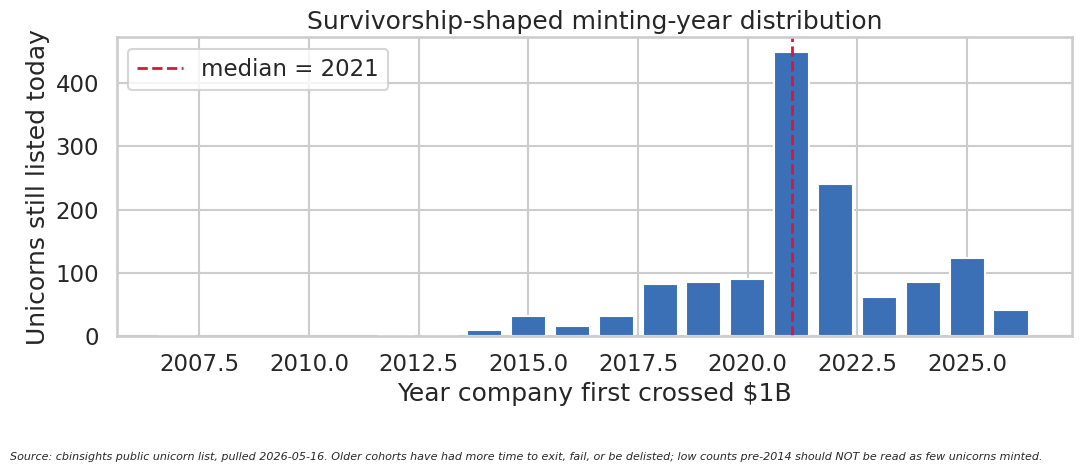

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(yr_counts.index, yr_counts.values, color='#3b6fb6', edgecolor='white')
med = valid['unicorn_year_num'].median()
ax.axvline(med, color='crimson', linestyle='--', linewidth=2,
           label=f'median = {int(med)}')
ax.set_xlabel('Year company first crossed $1B')
ax.set_ylabel('Unicorns still listed today')
ax.set_title('Survivorship-shaped minting-year distribution')
ax.legend()
fig.text(0.01, -0.06,
         f"Source: {pull_meta['source']} public unicorn list, pulled {pull_meta['date']}. "
         'Older cohorts have had more time to exit, fail, or be delisted; '
         'low counts pre-2014 should NOT be read as few unicorns minted.',
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()

*Figure 2 - Minting-year distribution among today's listed unicorns. Source: CB Insights, pulled on the date above. The leftward thinning is mostly attrition (exits, failures, delistings), not a real absence of unicorns minted before 2014.*

## 6. Tracker lag - how stale is the listing?

If `unicorn_year` is, say, 2014 but the pull date is 2026, that listing has had 12 years to be wrong. We compute the gap between `unicorn_year` and the pull date as a proxy for staleness. Older listings carry more risk of 'paper unicorn' status (stale 2021 marks, etc.).

In [11]:
pull_year = int(pull_meta['date'][:4]) if pull_meta['date'] != 'unknown' else 2026
valid['age_on_list'] = pull_year - valid['unicorn_year_num']
age_summary = valid['age_on_list'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(1)
print('Years since the company first crossed $1B (still listed):')
print(age_summary)
stale_share = (valid['age_on_list'] >= 5).mean()
print(f"\nshare of entries that are >= 5 years old on the list : {stale_share:.1%}")

Years since the company first crossed $1B (still listed):
count    1356.0
mean        4.8
std         2.5
min         0.0
25%         4.0
50%         5.0
75%         6.0
90%         8.0
max        19.0
Name: age_on_list, dtype: float64

share of entries that are >= 5 years old on the list : 59.3%


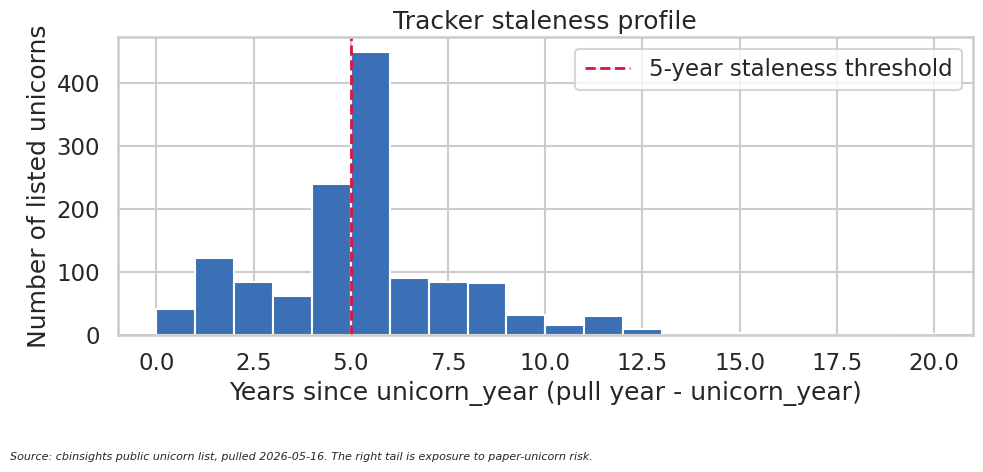

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
bins = range(0, int(valid['age_on_list'].max()) + 2)
ax.hist(valid['age_on_list'], bins=bins, color='#3b6fb6', edgecolor='white')
ax.axvline(5, color='crimson', linestyle='--', linewidth=2,
           label='5-year staleness threshold')
ax.set_xlabel('Years since unicorn_year (pull year - unicorn_year)')
ax.set_ylabel('Number of listed unicorns')
ax.set_title('Tracker staleness profile')
ax.legend()
fig.text(0.01, -0.06,
         f"Source: {pull_meta['source']} public unicorn list, pulled {pull_meta['date']}. "
         'The right tail is exposure to paper-unicorn risk.',
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()

*Figure 3 - Distribution of (pull year - unicorn_year). Source: CB Insights, pulled on the date above. The right tail is the population most exposed to paper-unicorn risk (stale marks, undisclosed down-rounds).*

## 7. Founder coverage by region

Notebook 03's founder analyses are conditional on Wikipedia having a `Founder(s)` cell for the company. The cell below quantifies that coverage by region. Anything < 30% is, in this repo's working definition, 'directional only' and should not be quoted as a population statistic.

In [13]:
if not fnd.empty:
    covered = set(fnd['company'].astype(str).str.strip())
    df['has_founder_record'] = df['company'].astype(str).str.strip().isin(covered)
    cov_by_region = (
        df.groupby('region')['has_founder_record']
          .agg(['mean', 'size'])
          .rename(columns={'mean': 'covered_share', 'size': 'n_unicorns'})
          .sort_values('covered_share', ascending=False)
    )
    print(cov_by_region.round(3))
else:
    cov_by_region = pd.DataFrame()
    print('No founders.csv; skipping coverage-by-region.')

        covered_share  n_unicorns
region                           
IN              0.270          63
EU              0.138         188
US              0.120         783
Other           0.055         163
CN              0.025         159


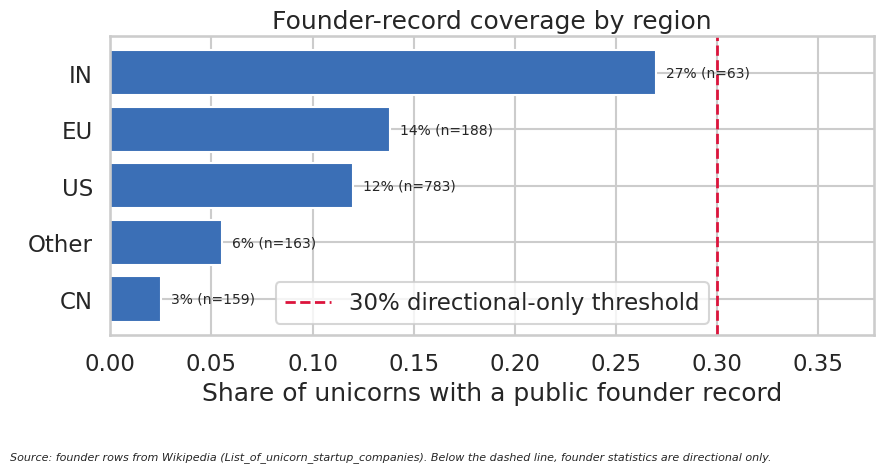

In [14]:
if not cov_by_region.empty:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    order = cov_by_region.sort_values('covered_share').index
    ax.barh(order, cov_by_region.loc[order, 'covered_share'], color='#3b6fb6')
    for i, region in enumerate(order):
        share = cov_by_region.loc[region, 'covered_share']
        n = int(cov_by_region.loc[region, 'n_unicorns'])
        ax.text(share + 0.005, i, f'{share:.0%} (n={n})', va='center', fontsize=10)
    ax.axvline(0.30, color='crimson', linestyle='--', linewidth=2,
               label='30% directional-only threshold')
    ax.set_xlim(0, max(cov_by_region['covered_share']) * 1.4)
    ax.set_xlabel('Share of unicorns with a public founder record')
    ax.set_title('Founder-record coverage by region')
    ax.legend()
    fig.text(0.01, -0.06,
             'Source: founder rows from Wikipedia (List_of_unicorn_startup_companies). '
             'Below the dashed line, founder statistics are directional only.',
             fontsize=8, style='italic')
    plt.tight_layout()
    plt.show()

*Figure 4 - Founder coverage by region. Every region is below 30%. Notebook 03 should therefore be read as a study of the covered subsample, not as a population-level statement about unicorn founders.*

## 8. Near-duplicate company names

A common public-data trap: the same company appears twice under near-identical names (case, punctuation, suffixes). The cell below normalizes names and flags collisions. Anything surfaced here is a candidate for hand-coding.

In [15]:
import re as _re
def _norm(name: str) -> str:
    s = str(name).lower().strip()
    s = _re.sub(r"[\.,\-'`]", '', s)
    s = _re.sub(r'\b(inc|llc|ltd|corp|co|group|holdings?|technologies|technology|labs?|ai)\b', '', s)
    s = _re.sub(r'\s+', ' ', s).strip()
    return s

df['name_norm'] = df['company'].apply(_norm)
collisions = (
    df.groupby('name_norm')
      .agg(n_rows=('company', 'size'),
           variants=('company', lambda s: sorted(set(s))),
           countries=('country', lambda s: sorted(set(s.dropna()))))
      .query('n_rows > 1')
      .sort_values('n_rows', ascending=False)
)
print(f"normalized-name collisions : {len(collisions)}")
collisions.head(15)

normalized-name collisions : 3


,n_rows,variants,countries
name_norm,,,
bolt,2,[Bolt],"[Estonia, United States]"
branch,2,[Branch],[United States]
fabric,2,[Fabric],[United States]


*Anything surfaced above is either a legitimate name collision (different companies, same brand) or a true duplicate. The validator in `scripts/validate_data.py` only fails when (company, country, sector, City) all match - looser keys are reviewed manually.*

## 9. What this data CAN and CANNOT support

This is the section future readers should cite when they want to know whether a finding in 01-03 generalizes.

**CAN support, with appropriate language:**

- *Sector and geography composition of the current unicorn list* (notebooks 01, 02). The completeness numbers above show the underlying columns are >95% populated; the sector taxonomy is clean on ~99.8% of rows.
- *Minting-year shape of today's surviving unicorns* (notebook 02), as long as the chart and caption both say 'surviving' or 'still listed'. The survivorship asymmetry visualized in section 5 is the irreducible caveat.
- *Directional statements about founder team size on the covered subsample* (notebook 03), as long as the chart says 'covered' or 'Wikipedia subsample'. Founder coverage is below 30% in every region (section 7), so the result is not a population statistic.
- *Coverage and bias measurement itself* - this notebook. The completeness numbers, taxonomy issues, and coverage gaps are publishable findings in their own right.

**CANNOT support, even with caveats:**

- *Unconditional rates of becoming a unicorn.* The denominator (every startup) is not in any of these sources.
- *Years-to-unicorn for the unicorn population.* CB Insights does not publish founding year; the Wikipedia subsample with founding years (~200 / 1,300+) is too biased to ground a population statistic.
- *Failure / down-round / demotion rates.* The tracker rarely removes companies; staleness in section 6 is the symptom.
- *Cross-region comparisons of founder traits.* Coverage in section 7 is differentially biased toward US/EU.
- *Causal claims of any kind.* Nothing in these data identifies a counterfactual.

**What would change a finding** (long form in `docs/METHODOLOGY.md` section 7): if founding-year coverage exceeded 80% across the unicorn list, the years-to-unicorn distribution could be reported as a population statistic. If the tracker published a removal log, the minting-year time series could be corrected for survivorship transparently.

## Save figures

Figures are auto-persisted by the `plt.show` hook installed in the Reproducibility cell at the top. The cell below just lists what was written so the run is self-documenting. Plotly figures are interactive and not exported here.

In [16]:
# Save key figures
from pathlib import Path
_slug = '04_data_quality_and_caveats'
_written = sorted(Path('figures').glob(f'{_slug}_fig*.png'))
print(f'{len(_written)} figure(s) saved to notebooks/figures/ for {_slug}:')
for p in _written:
    print(f'  {p}')


4 figure(s) saved to notebooks/figures/ for 04_data_quality_and_caveats:
  figures/04_data_quality_and_caveats_fig1.png
  figures/04_data_quality_and_caveats_fig2.png
  figures/04_data_quality_and_caveats_fig3.png
  figures/04_data_quality_and_caveats_fig4.png
